# Summary

03_latent_features.ipynb

Latent embedding exploration. Run inference with outputs=["latent"] on a small set of scans, load latent_embeddings.npy, and PCA/UMAP dimensionality reduction with a scatter plot coloured by level of perturbation. This demonstrates the potential utility of the latent representations, even in a toy dataset.

# Install

Unfortunately due to dependency conflicts between Tensorflow 2.13 and ipython, installation needs to take place outside the notebook in your ipykernel environment (unless you're running a kernel from the NeuroFM docker container, then you can skip this step).

Please run the following in your terminal Python environment before starting the kernel (mamba, etc.) to create and activate a dedicated environment, then install dependencies:
```bash
pip install "neurofm[notebooks] @ git+https://github.com/rockNroll87q/NeuroFM.git"
pip install templateflow==24.1.0 "numpy<=1.24.3" "typing-extensions<4.6.0"
```

**Note:** The `typing-extensions` pin is required for TensorFlow compatibility. Installing inside the notebook is not recommended as it conflicts with ipython's own dependencies. 


If you run into issues, we recommend using the NeuroFM notebook docker container `rocknroll87q/neurofm:notebook`:

Run: `docker run --rm -p 8888:8888 rocknroll87q/neurofm:notebook`.

Open your browser to `http://localhost:8888`.

In [ ]:
%pip install umap-learn

# Inference tests

In [ ]:
# First import takes ~ 30-40s due to internal TensorFlow imports
import re
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from neurofm import NeuroFM
from neurofm.io import (
    infer_input_root,
    resolve_inputs,
    save_batch_summary,
)
from neurofm.model import BRAIN_HEALTH_KEYS


### Config options

In [2]:
NEUROFM_VARIANT = 'neurofm-s'
DEVICE = 'cpu'
OUT_ROOT = Path('/tmp/neurofm_results')

## Generate template test vols

In this example, we generate skull-stripped test volumes as our input MRI data. You can replace this test data with your preferred dataset of choice.

In [3]:
!python ../scripts/get_test_data.py --output /tmp/test_data/ --mode synthetic -n 100
!python ../scripts/get_test_data.py --output /tmp/test_data/ --mode template -n 100


NeuroFM test data utility
  Mode   : synthetic
  Output : /tmp/test_data/
  N      : 100

Generating synthetic volume 1/100...
  Written: /tmp/test_data/synthetic_test_01.nii.gz  (shape: (182, 218, 182), dtype: float32)
Generating synthetic volume 2/100...
  Written: /tmp/test_data/synthetic_test_02.nii.gz  (shape: (182, 218, 182), dtype: float32)
Generating synthetic volume 3/100...
  Written: /tmp/test_data/synthetic_test_03.nii.gz  (shape: (182, 218, 182), dtype: float32)
Generating synthetic volume 4/100...
  Written: /tmp/test_data/synthetic_test_04.nii.gz  (shape: (182, 218, 182), dtype: float32)
Generating synthetic volume 5/100...
  Written: /tmp/test_data/synthetic_test_05.nii.gz  (shape: (182, 218, 182), dtype: float32)
Generating synthetic volume 6/100...
  Written: /tmp/test_data/synthetic_test_06.nii.gz  (shape: (182, 218, 182), dtype: float32)
Generating synthetic volume 7/100...
  Written: /tmp/test_data/synthetic_test_07.nii.gz  (shape: (182, 218, 182), dtype: float32)

## Get input paths

In `neurofm`, `resolve_inputs` is a utility to get the input paths from a single image, directory, or a .csv. The function assumes the input column containing your path strings is "input", but this can be changed with `resolve_inputs(..., input_col="path_col")`.

In [4]:
dataset_root = Path('/tmp/test_data/') # load the dir rather than the .csv to get both templates and synthetic/random vols
input_paths = resolve_inputs(dataset_root)
input_root = infer_input_root(input_paths)
input_root = Path(input_root)

2026-03-26 16:07:11.855 | INFO     | neurofm.io:resolve_inputs:76 - Resolved 200 input file(s).


In [5]:
input_paths

[PosixPath('/tmp/test_data/MNI152_test_01.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_02.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_03.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_04.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_05.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_06.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_07.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_08.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_09.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_10.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_100.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_11.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_12.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_13.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_14.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_15.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_16.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_17.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_18.nii.gz'),
 PosixPath(

## Run NeuroFM Inference

### Perturbation

In [6]:

class LinearPerturbation:
    """
    Stateful callable that applies a linearly increasing perturbation
    to each volume it processes, in call order.

    Designed to be passed as custom_preproc_fn to NeuroFM. Since volumes
    are processed sequentially, call index maps directly to perturbation scale.

    Templates are expected to be processed first (sorted input_paths puts
    MNI152_* before synthetic_* alphabetically). Synthetic volumes receive
    no perturbation - they are their own control condition.
    """
    def __init__(self, n_templates: int, max_noise_std: float, max_translation: float):
        self.n_templates = n_templates
        self.max_noise_std = max_noise_std
        self.max_translation = max_translation
        self._call_idx = 0
        self.perturbation_scales = []   # record scale applied to each volume
        self._direction = np.array([1.0, 1.0, 1.0])  # fixed diagonal direction

    def __call__(self, vol: np.ndarray) -> np.ndarray:
        idx = self._call_idx
        self._call_idx += 1

        if idx >= self.n_templates:
            # Synthetic volume - no perturbation
            self.perturbation_scales.append(0.0)
            return vol

        # Linear scale: 0.0 for first template, 1.0 for last
        scale = idx / max(self.n_templates - 1, 1)
        self.perturbation_scales.append(scale)

        noise_std = scale * self.max_noise_std
        shift_vox = scale * self.max_translation

        # Additive Gaussian noise
        if noise_std > 0:
            vol = vol + np.random.normal(0.0, noise_std, size=vol.shape).astype(np.float32)

        # Rigid translation - shift uniformly along all axes
        if shift_vox > 0:
            from scipy.ndimage import shift
            # direction = np.random.choice([-1, 1], size=3)
            # vol = shift(vol, shift=direction * shift_vox, order=1, cval=0.0)
            vol = shift(vol, shift=self._direction * shift_vox, order=1, cval=0.0)

        return np.clip(vol, 0.0, None)   # keep non-negative after noise

    def reset(self):
        self._call_idx = 0
        self.perturbation_scales = []


Produce a linear gradient of perturbations, hopefully seen clearly in the latent space

In [7]:
# Separate template paths from synthetic paths by filename
template_paths = sorted([p for p in input_paths if "MNI152" in Path(p).name])
synthetic_paths = sorted([p for p in input_paths if "synthetic" in Path(p).name])

n_templates = len(template_paths)
n_synthetic = len(synthetic_paths)

print(f"Templates : {n_templates}")
print(f"Synthetic : {n_synthetic}")
print(f"Total     : {len(input_paths)}")

# Linear perturbation scale for templates: 0.0 -> MAX_PERTURBATION
# Synthetic volumes are unperturbed (scale = 0)
MAX_NOISE_STD = 0.30       # max noise std dev added to template
MAX_TRANSLATION = 15.0     # max voxel shift (applied to all 3 axes)

perturb_fn = LinearPerturbation(n_templates, MAX_NOISE_STD, MAX_TRANSLATION)

print(f"\nPerturbation range: noise std 0.00 -> {MAX_NOISE_STD:.2f}, "
      f"translation 0 -> {MAX_TRANSLATION:.0f} vox")

Templates : 100
Synthetic : 100
Total     : 200

Perturbation range: noise std 0.00 -> 0.30, translation 0 -> 15 vox


### Run inference with perturbation

Runs about 10 minutes on CPU with NeuroFM-S

In [8]:
# input_paths must be sorted so templates come before synthetic
# (resolve_inputs sorts alphabetically; MNI152_* < synthetic_*)
input_paths_sorted = sorted(input_paths)

perturb_fn.reset()

model = NeuroFM(
    variant=NEUROFM_VARIANT,
    device=DEVICE,
    custom_preproc_fn=perturb_fn,
)

batch_results = model.predict_batch(input_paths_sorted, outputs=["brain_health", "latent"])

# Recover perturbation scales (one per volume, in processing order)
perturbation_scales = np.array(perturb_fn.perturbation_scales)

# Labels: 0 = template, 1 = synthetic
labels = np.array(
    ["template"] * n_templates + ["synthetic"] * n_synthetic
)

print(f"\nProcessed {len(batch_results)} volumes.")
print(f"Perturbation scales (templates): "
      f"{perturbation_scales[:n_templates].min():.2f} -> "
      f"{perturbation_scales[:n_templates].max():.2f}")

2026-03-26 16:07:31.578 | INFO     | neurofm.inference:_configure_device:221 - Device set to CPU (GPU disabled).
2026-03-26 16:07:31.580 | INFO     | neurofm.weights:get_weights_path:89 - Loading weights for neurofm-s (484k params). Downloading from HuggingFace if not cached...
2026-03-26 16:07:32.014 | INFO     | neurofm.weights:get_weights_path:100 - Weights ready: /Users/austind/.cache/NeuroFM/models--rocknroll87q--NeuroFM/snapshots/c6186ef7ba317a0ef1e36cdc7d59345edcf05e8d/neurofm-s.h5
2026-03-26 16:07:32.015 | INFO     | neurofm.model:load_neurofm:182 - Building neurofm-s architecture...
2026-03-26 16:07:32.419 | INFO     | neurofm.model:load_neurofm:185 - Loading weights from /Users/austind/.cache/NeuroFM/models--rocknroll87q--NeuroFM/snapshots/c6186ef7ba317a0ef1e36cdc7d59345edcf05e8d/neurofm-s.h5...
2026-03-26 16:07:32.460 | INFO     | neurofm.model:load_neurofm:188 - Model ready — 481,709 parameters.
2026-03-26 16:07:32.460 | INFO     | neurofm.inference:__init__:79 - NeuroFM re


Processed 200 volumes.
Perturbation scales (templates): 0.00 -> 1.00


Extract latent embeddings

In [9]:
latents = np.stack([r["latent"] for r in batch_results], axis=0)  # (N, D)
print(f"Latent array shape: {latents.shape}")

Latent array shape: (200, 160)


### Visualize Projections

UMAP projection

In [ ]:
try:
    import umap
except ImportError:
    raise ImportError(  # noqa: B904
        "umap-learn is required for this notebook.\n"
        "Install with: pip install umap-learn"
    )

np.random.seed(42)

reducer = umap.UMAP(
    n_neighbors=10,       # low neighbours appropriate for small N
    min_dist=0.7,
    n_components=2,
    random_state=42,
    metric="euclidean",
)

embedding = reducer.fit_transform(latents)   # (N, 2)

Plot visuals

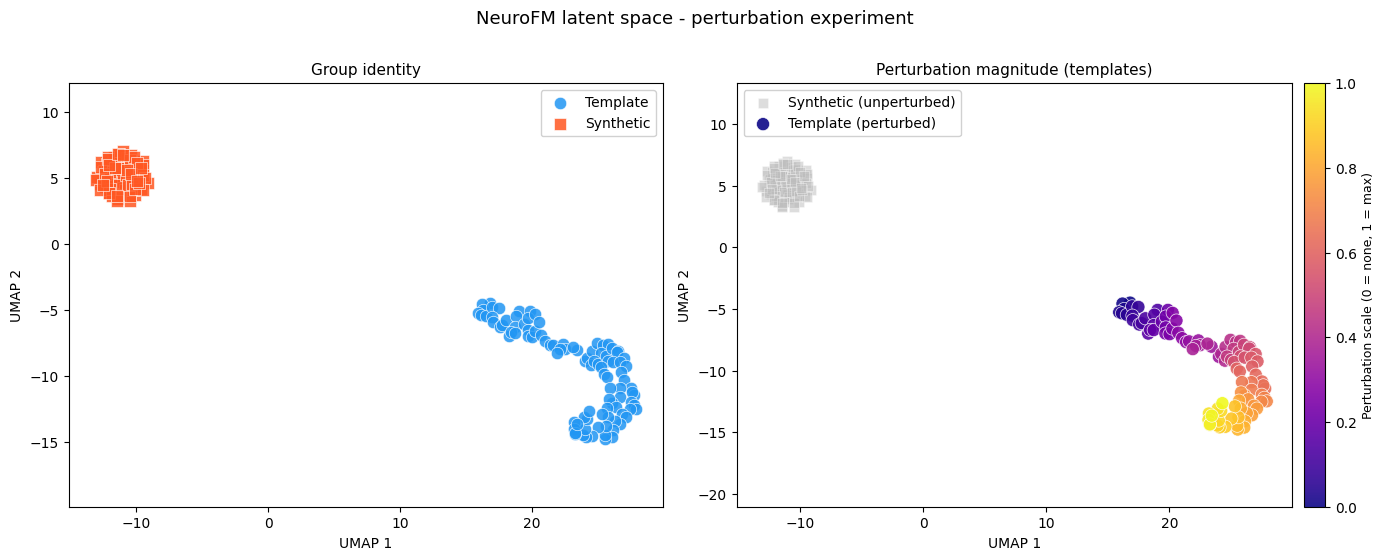


Note: UMAP layout is stochastic at small N. Cluster structure (templates grouped, synthetics distributed) is the meaningful signal, not the absolute positions.


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("NeuroFM latent space - perturbation experiment", fontsize=13, y=1.01)

# --- Panel A: coloured by group (template vs synthetic) ---
ax = axes[0]
colors_group = {"template": "#2196F3", "synthetic": "#FF5722"}
markers_group = {"template": "o", "synthetic": "s"}

for group in ["template", "synthetic"]:
    mask = labels == group
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=colors_group[group],
        marker=markers_group[group],
        s=80, alpha=0.85, edgecolors="white", linewidths=0.5,
        label=group.capitalize(),
    )

ax.set_title("Group identity", fontsize=11)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(framealpha=0.9)
ax.set_aspect("equal", "datalim")

# --- Panel B: templates coloured by perturbation scale ---
ax = axes[1]

# Synthetic as muted background
synthetic_mask = labels == "synthetic"
ax.scatter(
    embedding[synthetic_mask, 0], embedding[synthetic_mask, 1],
    c="#BDBDBD", marker="s", s=60, alpha=0.5,
    edgecolors="white", linewidths=0.5,
    label="Synthetic (unperturbed)",
    zorder=1,
)

# Templates coloured by perturbation scale
template_mask = labels == "template"
sc = ax.scatter(
    embedding[template_mask, 0], embedding[template_mask, 1],
    c=perturbation_scales[template_mask],
    cmap="plasma",
    vmin=0.0, vmax=1.0,
    marker="o", s=90, alpha=0.9,
    edgecolors="white", linewidths=0.5,
    label="Template (perturbed)",
    zorder=2,
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("Perturbation scale (0 = none, 1 = max)", fontsize=9)

ax.set_title("Perturbation magnitude (templates)", fontsize=11)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(framealpha=0.9, loc="upper left")
ax.set_aspect("equal", "datalim")

plt.tight_layout()
plt.savefig("latent_perturbation_umap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNote: UMAP layout is stochastic at small N. Cluster structure "
      "(templates grouped, synthetics distributed) is the meaningful signal, "
      "not the absolute positions.")

In the above visual, we can see that the synthetic (elliptical noise volumes; orange) are completely distinct in the latent space from the template brains (blue). Additionally, as the template brains move in the volume space, we can see that movement encoded by the output latent representation (right plot, color-coded by position).

This is a somewhat basic example due to the difficulty in providing real test data for the repository, but it demonstrates how the latent representation encodes many different things about the brain and the volume space. We have more scientifically interesting examples in the accompanying NeuroFM publication.